# Tugas 2 - Numerical Methods & Programming

**Nama**  : Rifqi Pasha Alviansyah  
**NIM**   : 12224010  
**Kelas** : K-02


## Problem 1

Pada soal ini akan dicari akar dari persamaan:

f(x) = -12 - 21x + 18x² - 2.75x³

Metode yang digunakan:
- Bisection Method
- False Position Method

Interval awal yang diberikan adalah [-1, 0] dengan kriteria berhenti 4 significant figures (es = 0.005)

### 1.1 Pendefinisian Fungsi

Berikut adalah pendefinisian fungsi sesuai dengan soal.  
Selain itu juga ditentukan nilai error toleransi berdasarkan 4 significant figures.

In [26]:
# Import library yang dibutuhkan
import numpy as np
import matplotlib.pyplot as plt

# Fungsi pada soal
f = lambda x: -12 - 21*x + 18*x**2 - 2.75*x**3

# Untuk plotting
x_plot = np.linspace(-2, 1.5, 400)

# 4 significant figures
es = 0.005

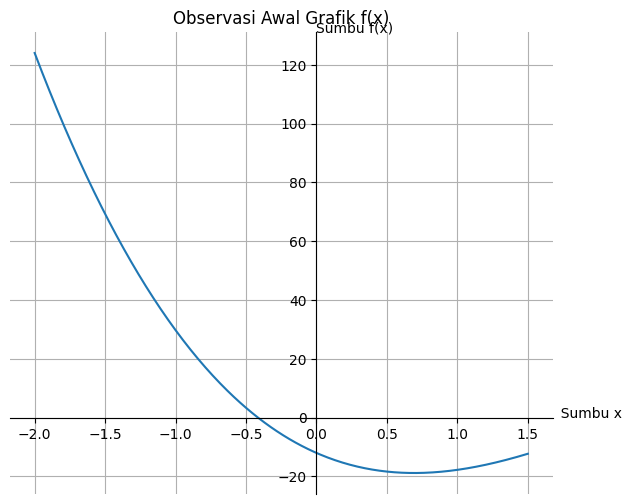

In [27]:
# Mencoba memplotting grafik fungsi dalam koordinat kartesius
fig, ax = plt.subplots(figsize=(7,6))

ax.plot(x_plot, f(x_plot))

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.text(ax.get_xlim()[1], 0, "  Sumbu x")
ax.text(0, ax.get_ylim()[1], "Sumbu f(x)")

ax.set_title("Observasi Awal Grafik f(x)")
ax.grid(True)

plt.show()

### 1.2 Metode Bisection

Metode Bisection dilakukan dengan membagi dua interval setiap iterasi.  
Iterasi dihentikan ketika approximate percent error lebih kecil dari nilai error toleransi.

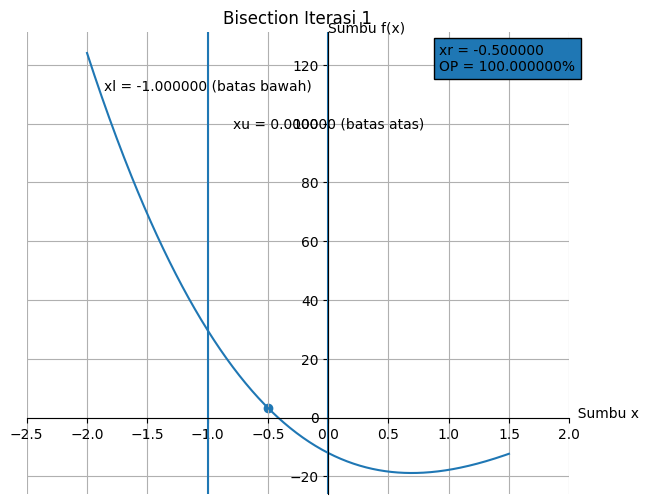

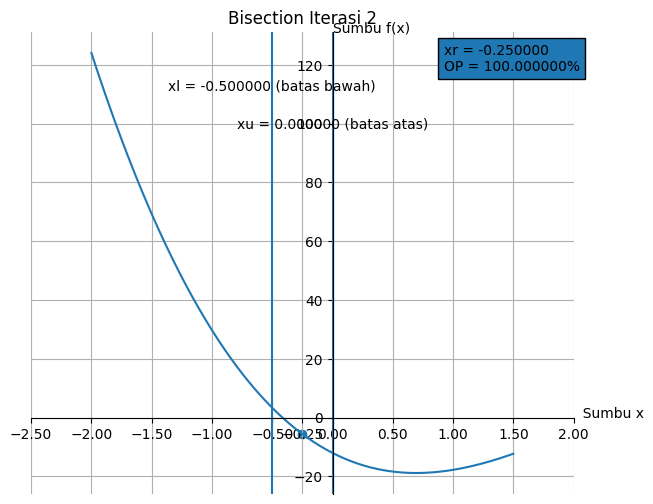

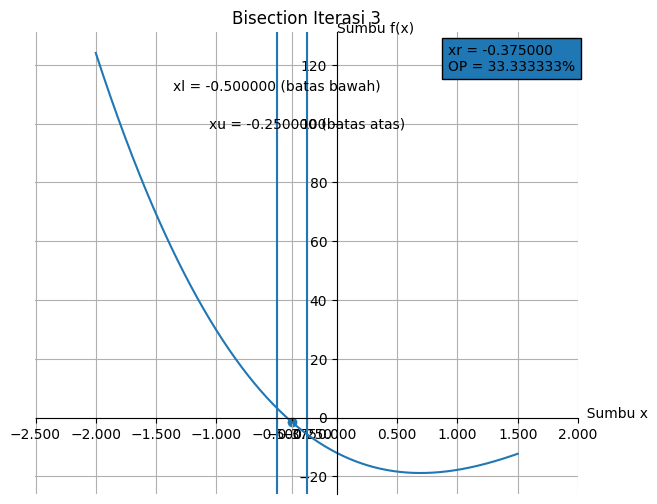

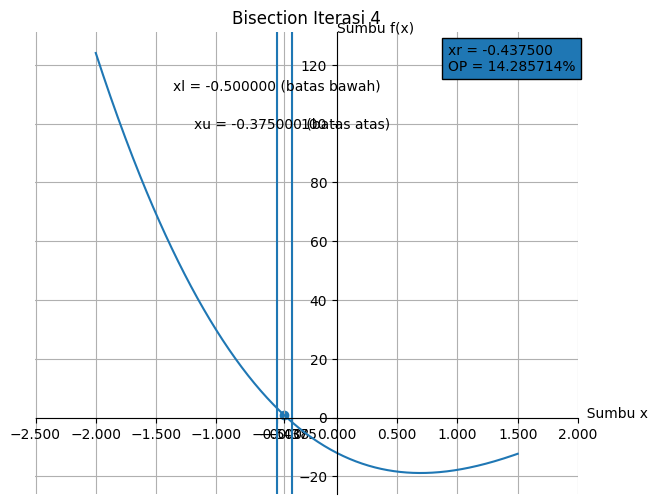

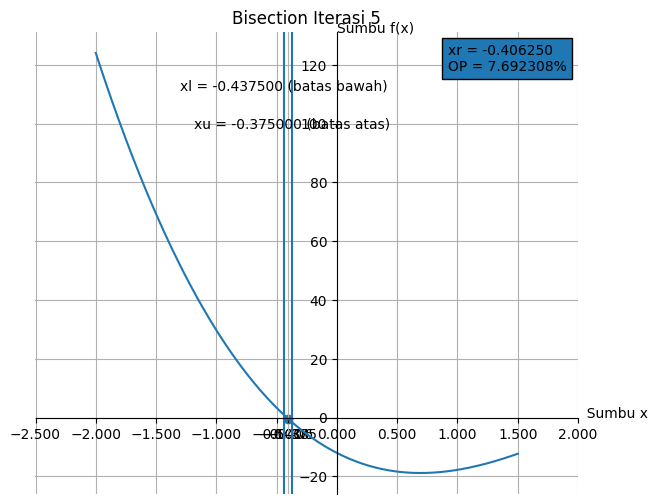

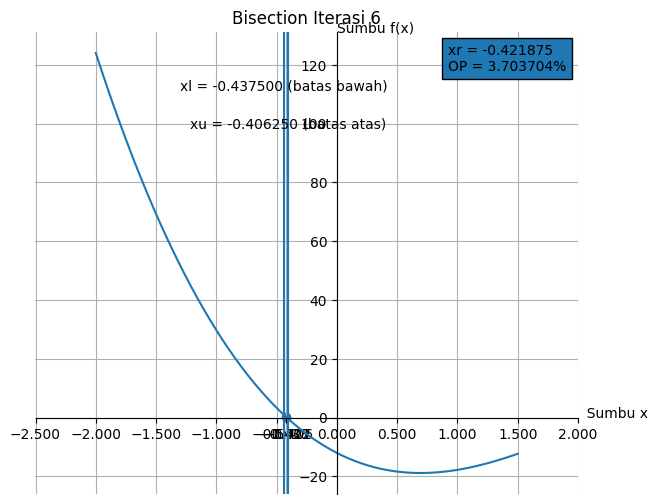

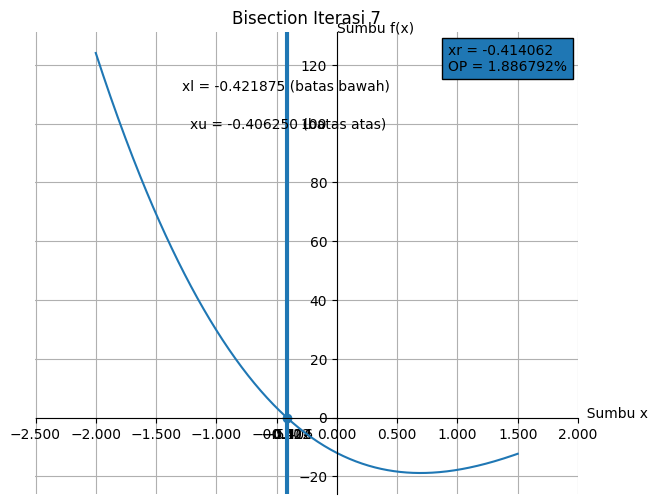

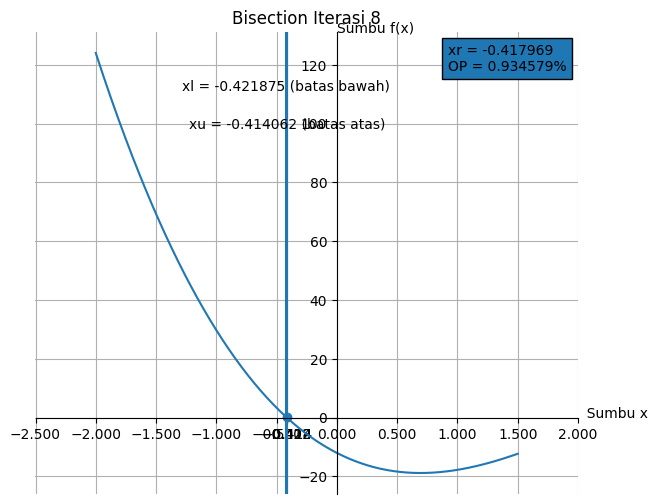

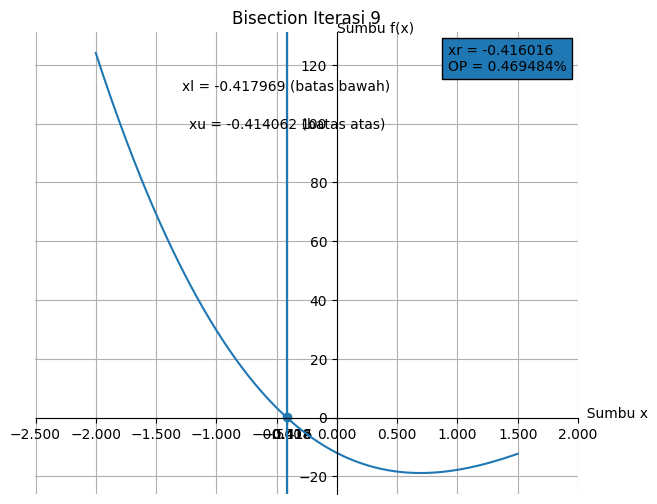

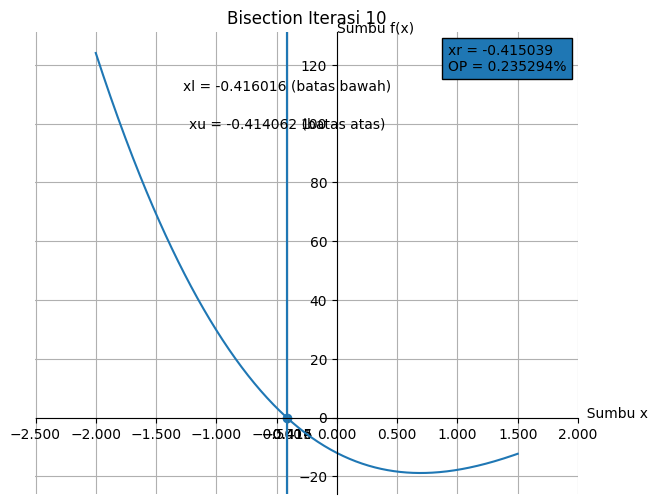

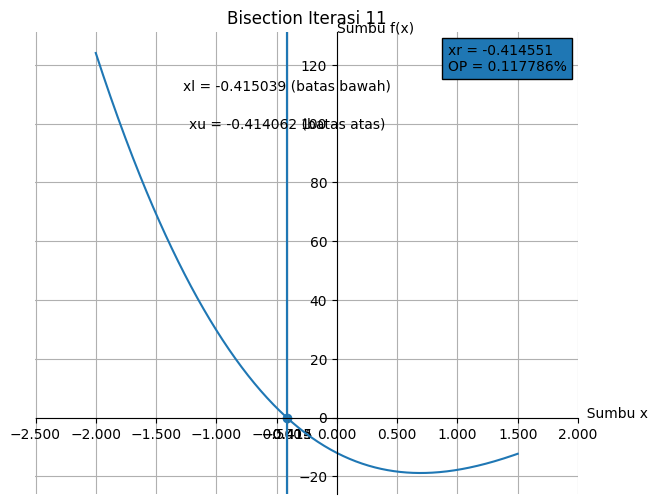

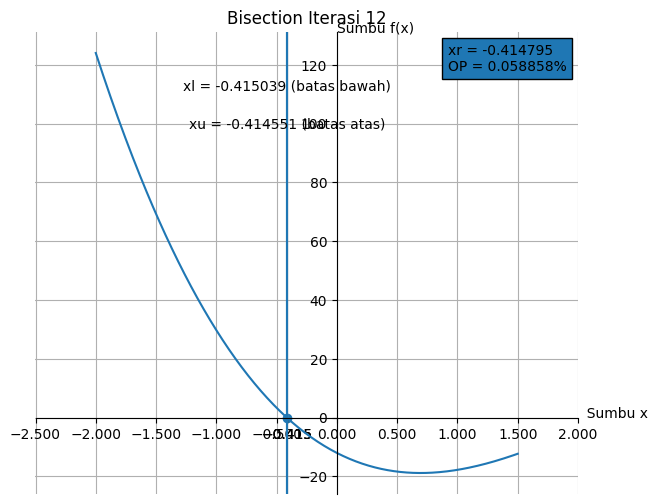

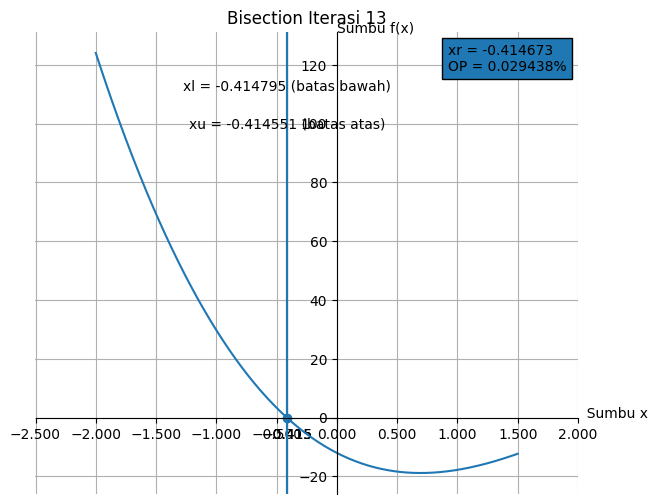

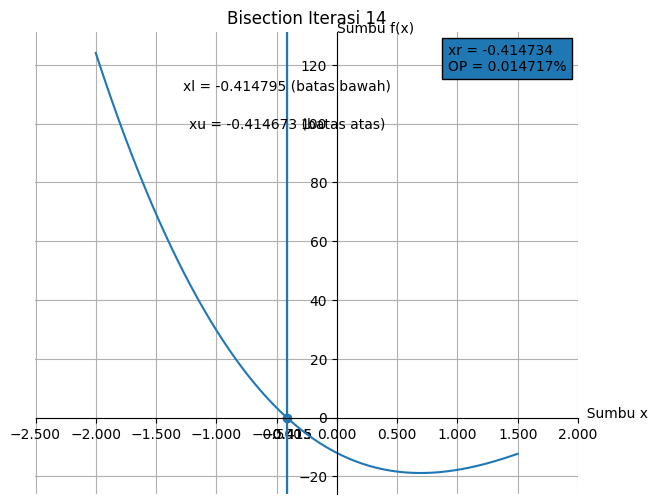

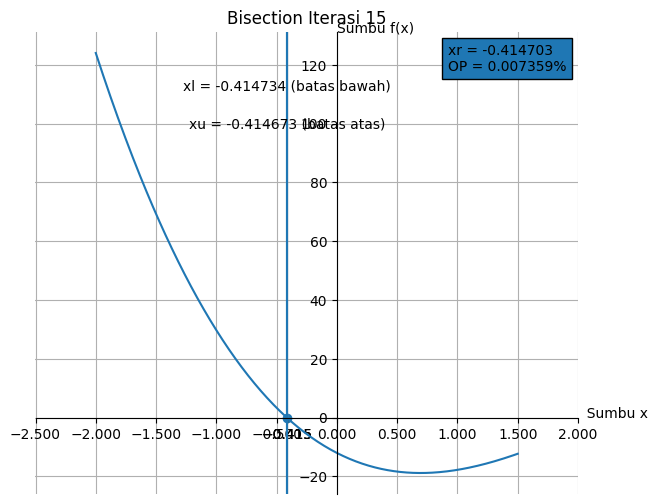

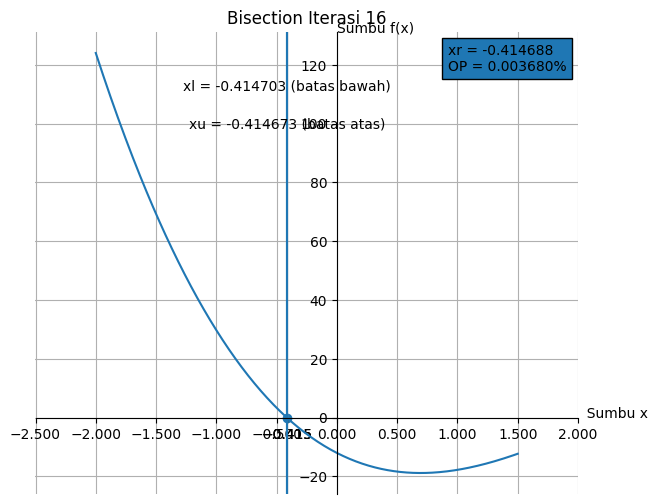

In [28]:
xl = -1
xu = 0
ea = 100
xr_lama = 0
iterasi = 0

error_bis = []
iter_bis = []

while ea > es:
    
    xr = (xl + xu)/2
    iterasi += 1
    
    if iterasi > 1:
        ea = abs((xr - xr_lama)/xr)*100
    
    error_bis.append(ea)
    iter_bis.append(iterasi)
    
    fig, ax = plt.subplots(figsize=(7,6))
    
    ax.plot(x_plot, f(x_plot))
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Garis batas bawah
    ax.axvline(xl)
    ax.text(xl, ax.get_ylim()[1]*0.85,
            f"xl = {xl:.6f} (batas bawah)",
            horizontalalignment='center')
    
    # Garis batas atas
    ax.axvline(xu)
    ax.text(xu, ax.get_ylim()[1]*0.75,
            f"xu = {xu:.6f} (batas atas)",
            horizontalalignment='center')
    
    # Titik xr
    ax.scatter(xr, f(xr))
    
    # Informasi xr di kanan atas
    ax.text(ax.get_xlim()[1]*0.55,
            ax.get_ylim()[1]*0.9,
            f"xr = {xr:.6f}\nOP = {ea:.6f}%",
            bbox=dict())
    
    # Paksa angka muncul di sumbu
    xticks = list(ax.get_xticks()) + [xl, xu, xr]
    ax.set_xticks(sorted(set(xticks)))
    
    ax.text(ax.get_xlim()[1], 0, "  Sumbu x")
    ax.text(0, ax.get_ylim()[1], "Sumbu f(x)")
    
    ax.set_title(f"Bisection Iterasi {iterasi}")
    ax.grid(True)
    plt.show()
    
    if f(xl)*f(xr) < 0:
        xu = xr
    else:
        xl = xr
        
    xr_lama = xr

### 1.3 Metode False Position

Metode False Position menggunakan pendekatan garis lurus (interpolasi linear) antara dua titik batas untuk menentukan akar hampiran.

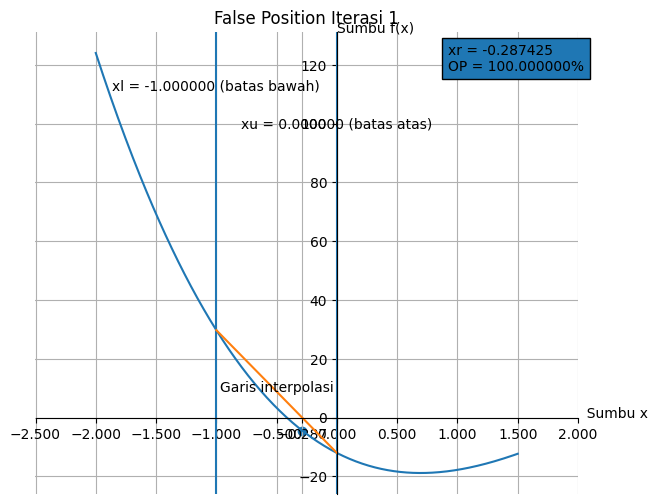

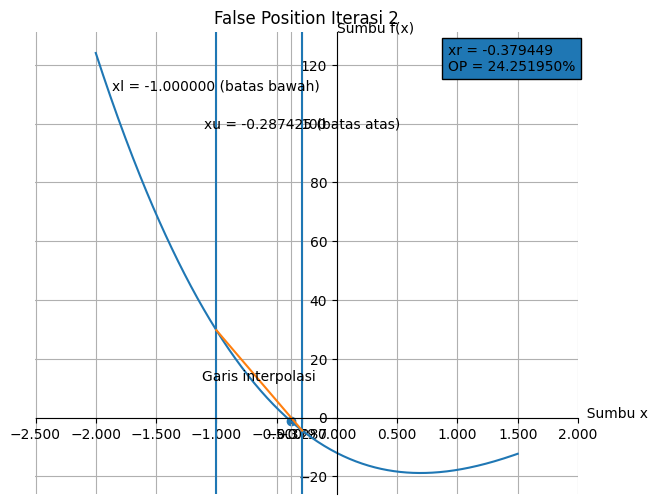

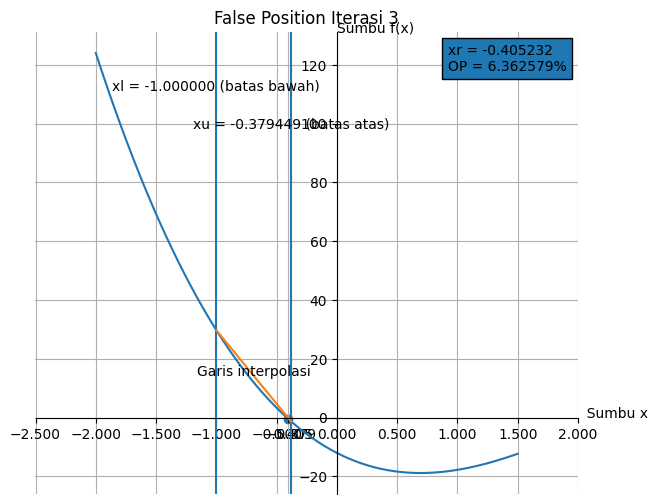

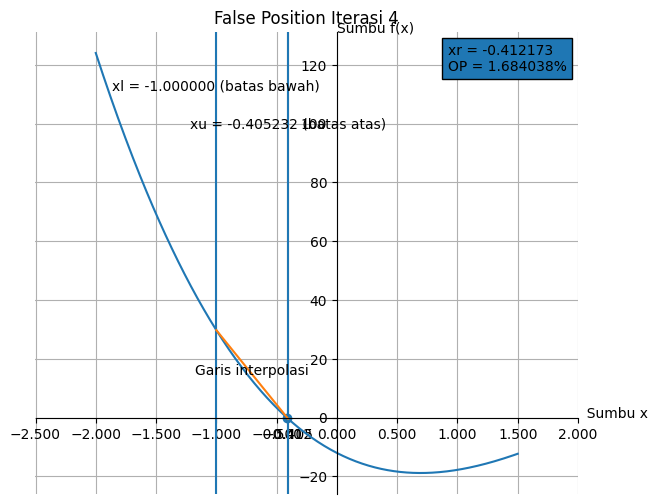

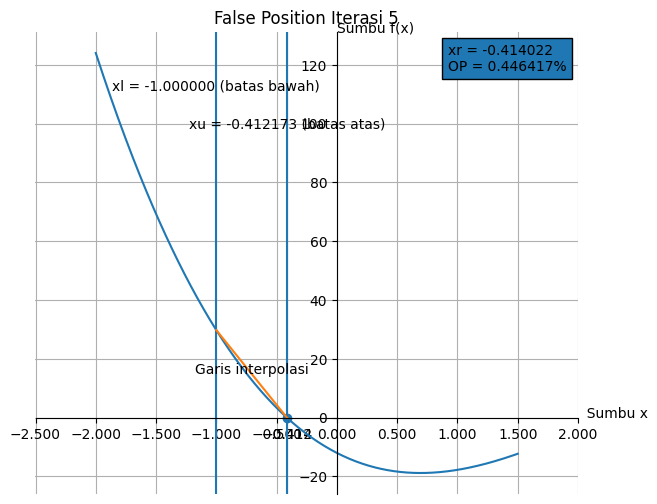

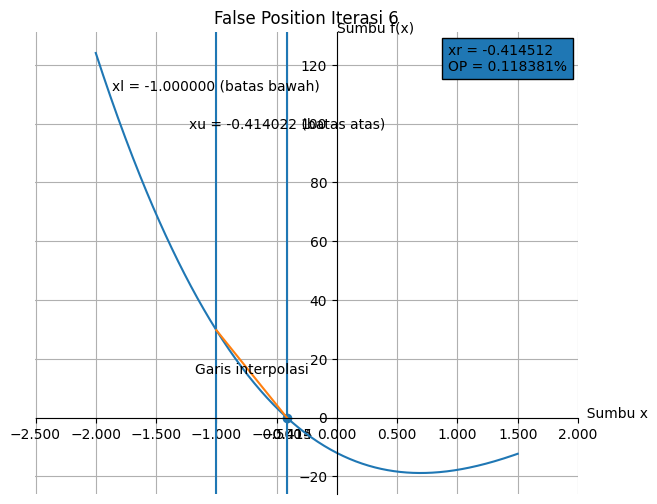

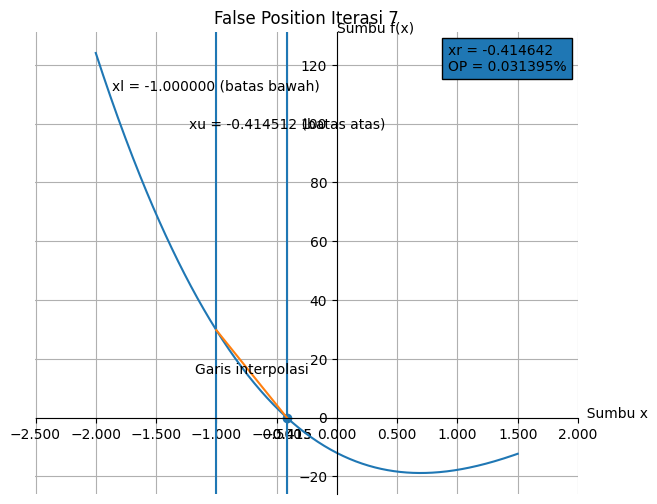

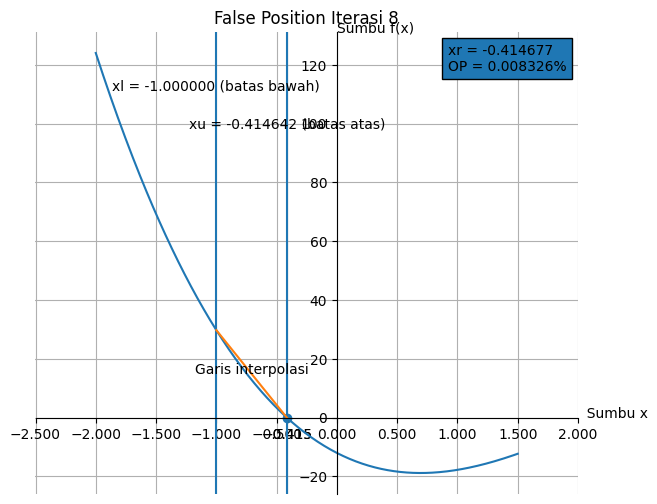

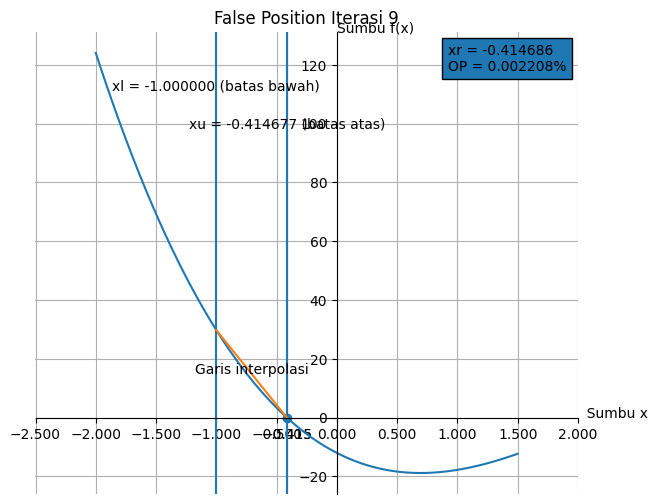

In [29]:
xl = -1
xu = 0
ea = 100
xr_lama = 0
iterasi = 0

error_fp = []
iter_fp = []

while ea > es:
    
    xr = xu - (f(xu)*(xl-xu))/(f(xl)-f(xu))
    iterasi += 1
    
    if iterasi > 1:
        ea = abs((xr - xr_lama)/xr)*100
    
    error_fp.append(ea)
    iter_fp.append(iterasi)
    
    fig, ax = plt.subplots(figsize=(7,6))
    
    ax.plot(x_plot, f(x_plot))
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    ax.axvline(xl)
    ax.text(xl, ax.get_ylim()[1]*0.85,
            f"xl = {xl:.6f} (batas bawah)",
            horizontalalignment='center')
    
    ax.axvline(xu)
    ax.text(xu, ax.get_ylim()[1]*0.75,
            f"xu = {xu:.6f} (batas atas)",
            horizontalalignment='center')
    
    # Garis interpolasi
    ax.plot([xl,xu],[f(xl),f(xu)])
    ax.text((xl+xu)/2,
            (f(xl)+f(xu))/2,
            "Garis interpolasi",
            horizontalalignment='center')
    
    ax.scatter(xr, f(xr))
    
    ax.text(ax.get_xlim()[1]*0.55,
            ax.get_ylim()[1]*0.9,
            f"xr = {xr:.6f}\nOP = {ea:.6f}%",
            bbox=dict())
    
    xticks = list(ax.get_xticks()) + [xl, xu, xr]
    ax.set_xticks(sorted(set(xticks)))
    
    ax.text(ax.get_xlim()[1], 0, "  Sumbu x")
    ax.text(0, ax.get_ylim()[1], "Sumbu f(x)")
    
    ax.set_title(f"False Position Iterasi {iterasi}")
    ax.grid(True)
    plt.show()
    
    if f(xl)*f(xr) < 0:
        xu = xr
    else:
        xl = xr
        
    xr_lama = xr

### 1.4 Kesimpulan dan Hubungan antara approximate percent error dengan jumlah iterasi

Pada bagian ini akan diberikan kesimpulan dan grafik yang menunjukkan hubungan antara approximate percent error dengan jumlah iterasi pada metode yang digunakan

=== Bisection Method (Problem 1) ===
Akar hampiran = -0.414686
Jumlah iterasi = 9
Error akhir = 0.002208%


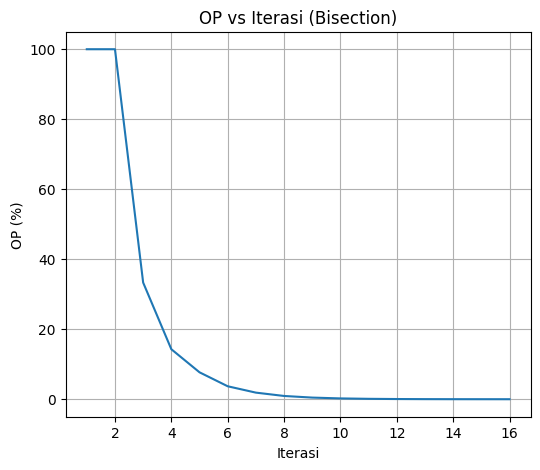

=== False Position Method (Problem 1) ===
Akar hampiran = -0.414686
Jumlah iterasi = 9
Error akhir = 0.002208%


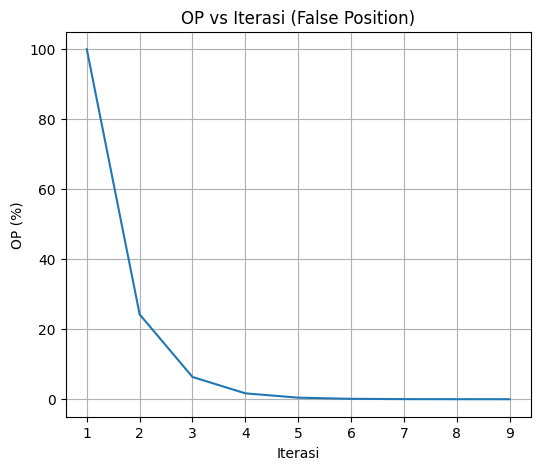

In [30]:
print("=== Bisection Method (Problem 1) ===")
print(f"Akar hampiran = {xr:.6f}")
print(f"Jumlah iterasi = {iterasi}")
print(f"Error akhir = {ea:.6f}%")

plt.figure(figsize=(6,5))
plt.plot(iter_bis, error_bis)
plt.title("OP vs Iterasi (Bisection)")
plt.xlabel("Iterasi")
plt.ylabel("OP (%)")
plt.grid(True)
plt.show()

print("=== False Position Method (Problem 1) ===")
print(f"Akar hampiran = {xr:.6f}")
print(f"Jumlah iterasi = {iterasi}")
print(f"Error akhir = {ea:.6f}%")

plt.figure(figsize=(6,5))
plt.plot(iter_fp, error_fp)
plt.title("OP vs Iterasi (False Position)")
plt.xlabel("Iterasi")
plt.ylabel("OP (%)")
plt.grid(True)
plt.show()

## Problem 2

Pada soal ini dicari nilai tinggi awal air (H) agar kecepatan aliran air mencapai 5 m/s dalam waktu 2.5 s.

Diketahui:
- g = 9.81 m/s²
- L = 4 m
- t = 2.5 s
- v target = 5 m/s

Persamaan disusun dalam bentuk f(H) = 0 agar dapat dicari akarnya menggunakan metode numerik.

### 2.1 Pendefinisian Fungsi

Fungsi berikut merupakan hasil penyusunan ulang persamaan kecepatan sehingga berbentuk f(H) = 0.

In [31]:
# Import library yang diperlukan
import numpy as np
import matplotlib.pyplot as plt

# Parameter diketahui
g = 9.81
L = 4
t = 2.5
v_target = 5

# Bentuk f(H) = 0
f = lambda H: np.sqrt(2*g*H)*np.tanh((np.sqrt(2*g*H)/(2*L))*t) - v_target

# Untuk plotting
H_plot = np.linspace(0,3,400)

# Stopping criterion OP < 1%
es = 1

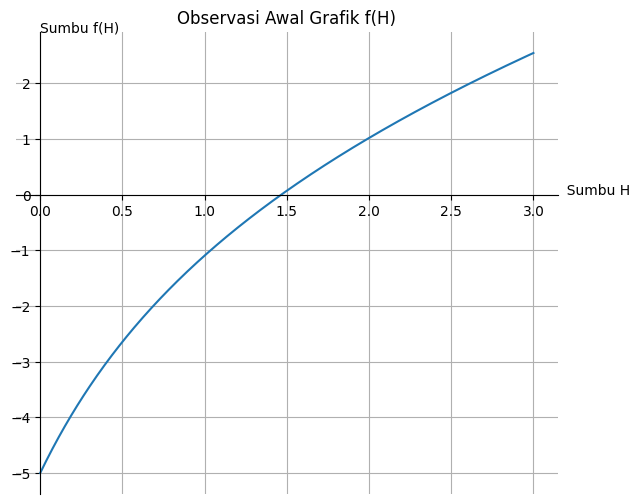

In [32]:
# Mencoba memplot grafik pada koordinat kartesius
fig, ax = plt.subplots(figsize=(7,6))

ax.plot(H_plot, f(H_plot))

# Sumbu kartesius
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.text(ax.get_xlim()[1], 0, "  Sumbu H")
ax.text(0, ax.get_ylim()[1], "Sumbu f(H)")

ax.set_title("Observasi Awal Grafik f(H)")
ax.grid(True)

plt.show()

### 2.2 Metode Bisection

Metode Bisection digunakan untuk mencari nilai H pada interval awal [0, 2].  
Iterasi dihentikan ketika approximate percent error kurang dari 1%.

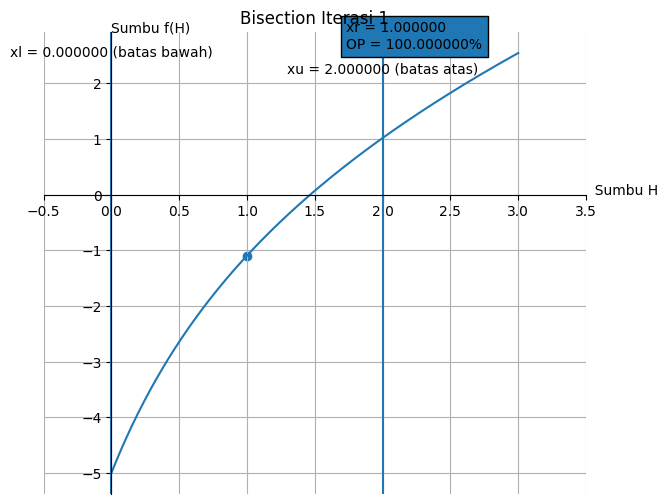

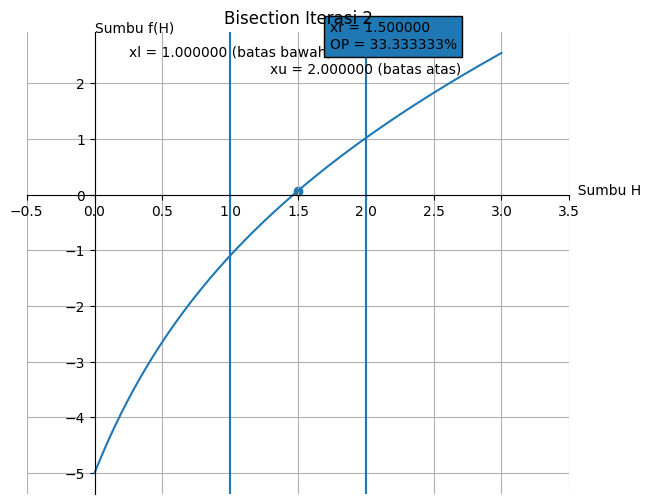

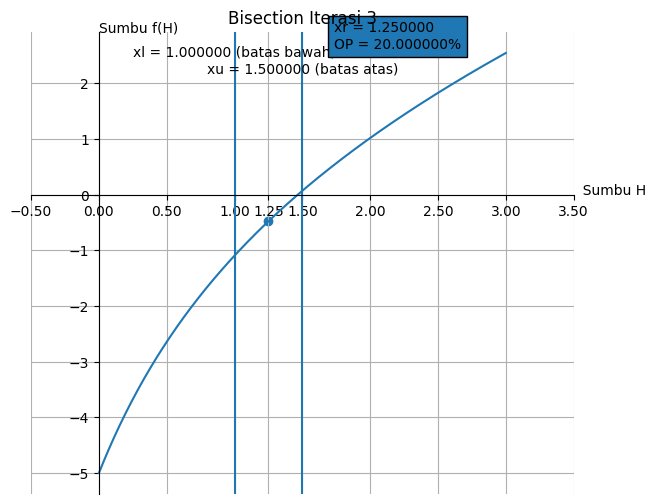

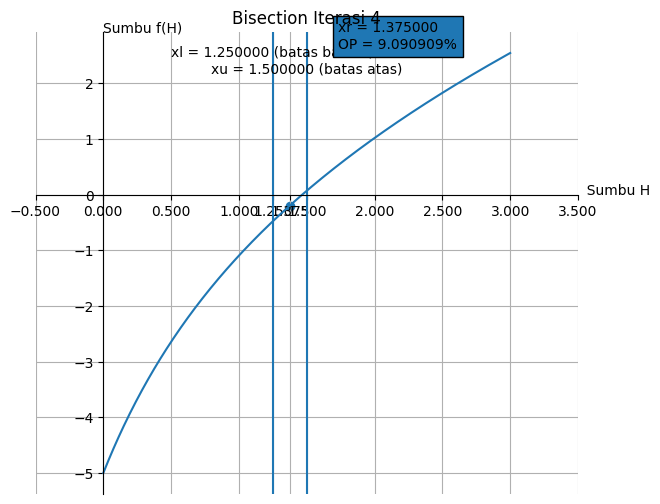

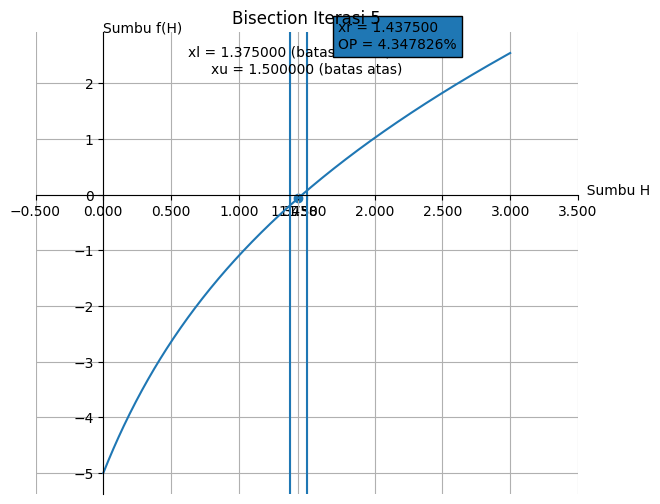

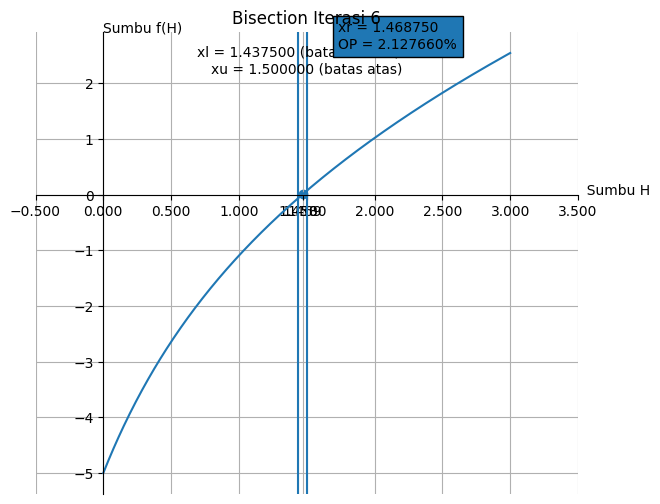

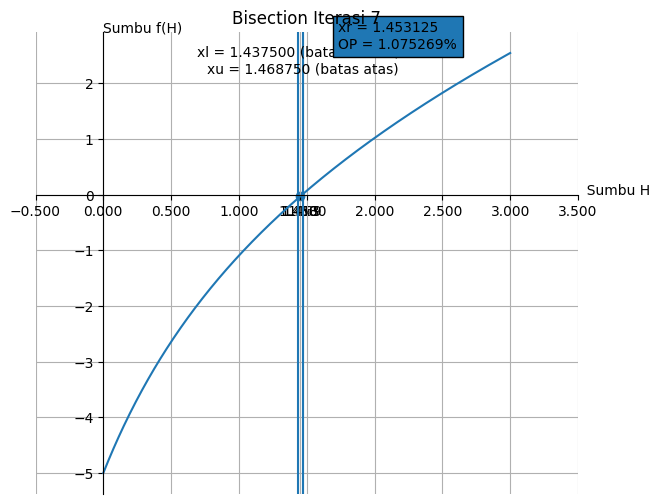

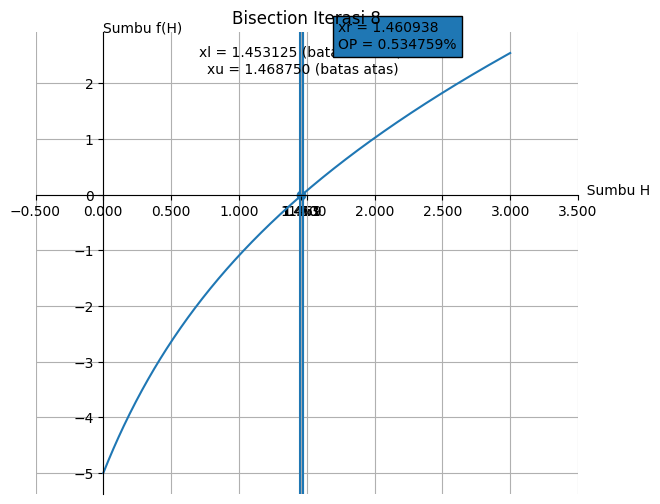

In [33]:
xl = 0
xu = 2
ea = 100
xr_lama = 0
iterasi = 0

error_bis2 = []
iter_bis2 = []

while ea > es:
    
    xr = (xl + xu)/2
    iterasi += 1
    
    if iterasi > 1:
        ea = abs((xr - xr_lama)/xr)*100
    
    error_bis2.append(ea)
    iter_bis2.append(iterasi)
    
    fig, ax = plt.subplots(figsize=(7,6))
    
    ax.plot(H_plot, f(H_plot))
    
    # Sumbu kartesius
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Garis batas bawah
    ax.axvline(xl)
    ax.text(xl, ax.get_ylim()[1]*0.85,
            f"xl = {xl:.6f} (batas bawah)",
            horizontalalignment='center')
    
    # Garis batas atas
    ax.axvline(xu)
    ax.text(xu, ax.get_ylim()[1]*0.75,
            f"xu = {xu:.6f} (batas atas)",
            horizontalalignment='center')
    
    # Titik xr
    ax.scatter(xr, f(xr))
    
    # Info xr + OP di kanan atas
    ax.text(ax.get_xlim()[1]*0.55,
            ax.get_ylim()[1]*0.9,
            f"xr = {xr:.6f}\nOP = {ea:.6f}%",
            bbox=dict())
    
    # Paksa nilai muncul di sumbu
    xticks = list(ax.get_xticks()) + [xl, xu, xr]
    ax.set_xticks(sorted(set(xticks)))
    
    ax.text(ax.get_xlim()[1], 0, "  Sumbu H")
    ax.text(0, ax.get_ylim()[1], "Sumbu f(H)")
    
    ax.set_title(f"Bisection Iterasi {iterasi}")
    ax.grid(True)
    plt.show()
    
    if f(xl)*f(xr) < 0:
        xu = xr
    else:
        xl = xr
        
    xr_lama = xr

### 2.3 Metode False Position

Metode False Position juga digunakan untuk mencari nilai H dengan interval awal yang sama.  
Perbandingan hasil dapat dilihat dari jumlah iterasi dan grafik error.

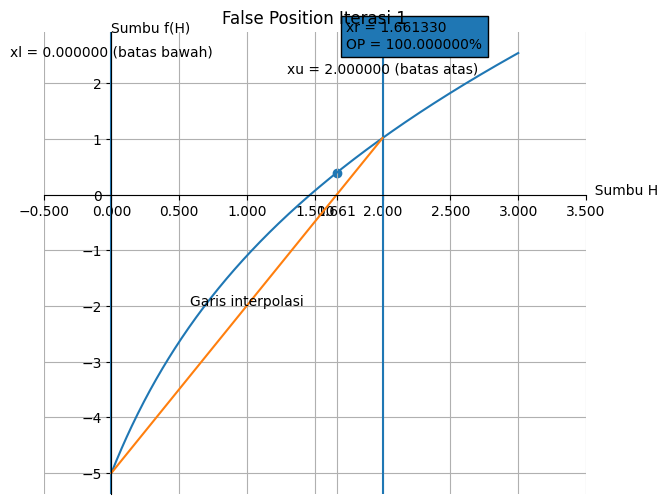

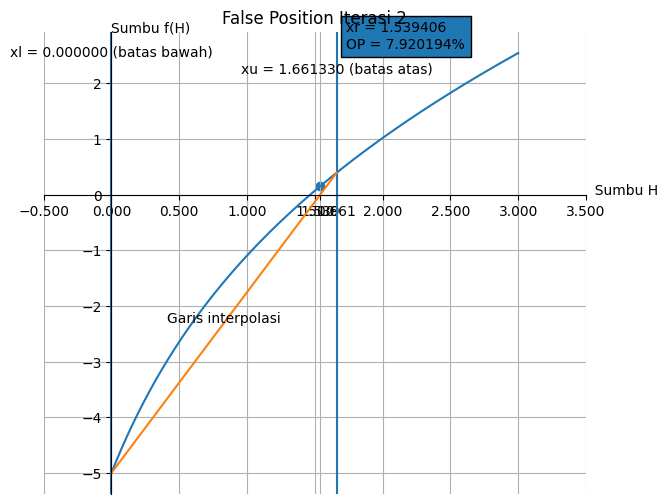

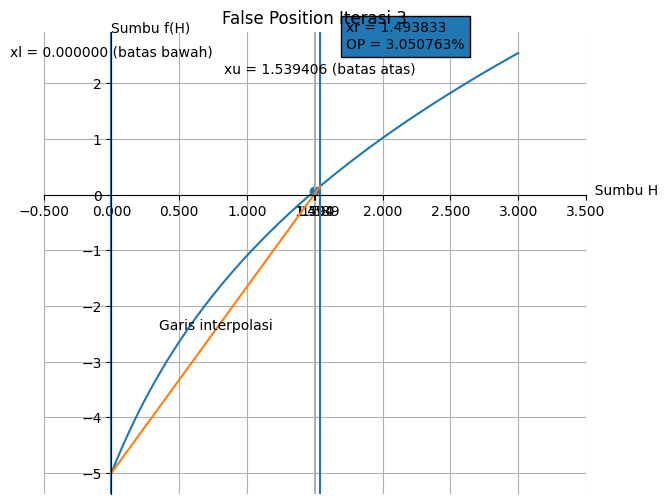

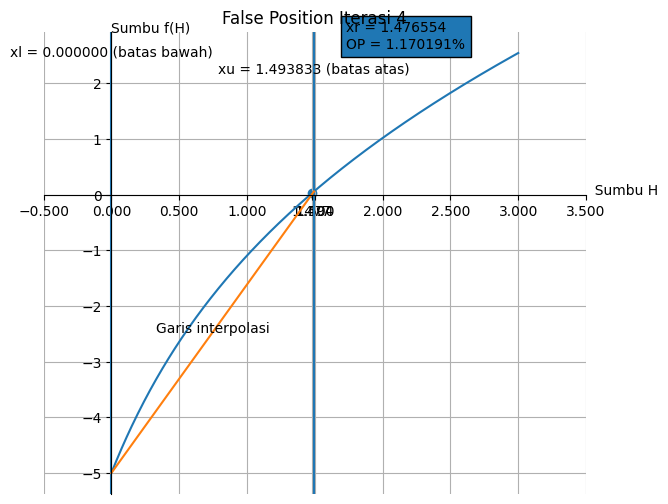

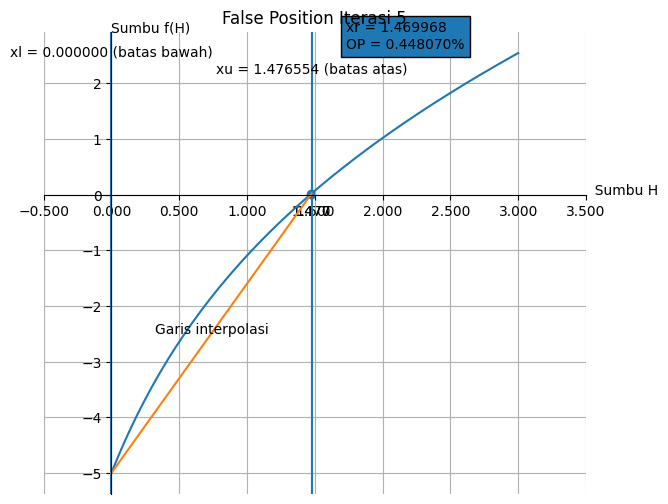

In [34]:
xl = 0
xu = 2
ea = 100
xr_lama = 0
iterasi = 0

error_fp2 = []
iter_fp2 = []

while ea > es:
    
    xr = xu - (f(xu)*(xl-xu))/(f(xl)-f(xu))
    iterasi += 1
    
    if iterasi > 1:
        ea = abs((xr - xr_lama)/xr)*100
    
    error_fp2.append(ea)
    iter_fp2.append(iterasi)
    
    fig, ax = plt.subplots(figsize=(7,6))
    
    ax.plot(H_plot, f(H_plot))
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Garis batas bawah
    ax.axvline(xl)
    ax.text(xl, ax.get_ylim()[1]*0.85,
            f"xl = {xl:.6f} (batas bawah)",
            horizontalalignment='center')
    
    # Garis batas atas
    ax.axvline(xu)
    ax.text(xu, ax.get_ylim()[1]*0.75,
            f"xu = {xu:.6f} (batas atas)",
            horizontalalignment='center')
    
    # Garis interpolasi
    ax.plot([xl,xu],[f(xl),f(xu)])
    ax.text((xl+xu)/2,
            (f(xl)+f(xu))/2,
            "Garis interpolasi",
            horizontalalignment='center')
    
    # Titik xr
    ax.scatter(xr, f(xr))
    
    # Info xr + OP
    ax.text(ax.get_xlim()[1]*0.55,
            ax.get_ylim()[1]*0.9,
            f"xr = {xr:.6f}\nOP = {ea:.6f}%",
            bbox=dict())
    
    xticks = list(ax.get_xticks()) + [xl, xu, xr]
    ax.set_xticks(sorted(set(xticks)))
    
    ax.text(ax.get_xlim()[1], 0, "  Sumbu H")
    ax.text(0, ax.get_ylim()[1], "Sumbu f(H)")
    
    ax.set_title(f"False Position Iterasi {iterasi}")
    ax.grid(True)
    plt.show()
    
    if f(xl)*f(xr) < 0:
        xu = xr
    else:
        xl = xr
        
    xr_lama = xr

### 2.4 Kesimpulan dan Hubungan antara approximate percent error dengan jumlah iterasi

Pada bagian ini akan diberikan kesimpulan dan grafik yang menunjukkan hubungan antara approximate percent error dengan jumlah iterasi pada metode yang digunakan

=== Bisection Method (Problem 2) ===
Nilai H yang diperoleh = 1.469968 m
Jumlah iterasi = 5
Error akhir = 0.448070%


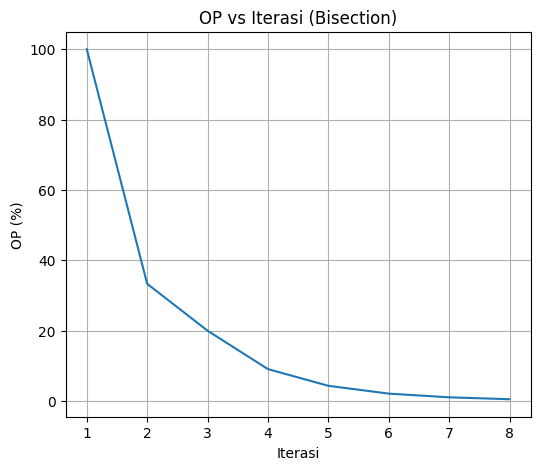

=== False Position Method (Problem 2) ===
Nilai H yang diperoleh = 1.469968 m
Jumlah iterasi = 5
Error akhir = 0.448070%


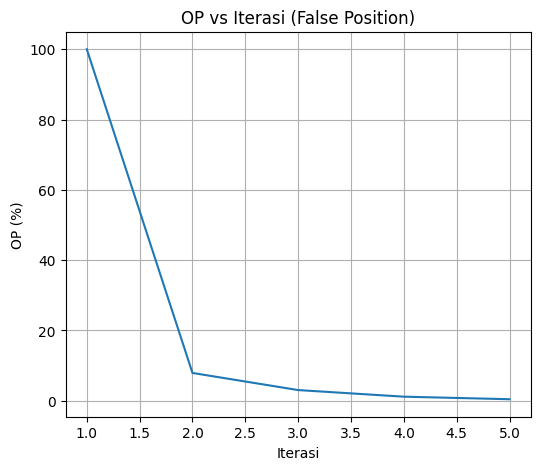

In [35]:
print("=== Bisection Method (Problem 2) ===")
print(f"Nilai H yang diperoleh = {xr:.6f} m")
print(f"Jumlah iterasi = {iterasi}")
print(f"Error akhir = {ea:.6f}%")

plt.figure(figsize=(6,5))
plt.plot(iter_bis2, error_bis2)
plt.title("OP vs Iterasi (Bisection)")
plt.xlabel("Iterasi")
plt.ylabel("OP (%)")
plt.grid(True)
plt.show()

print("=== False Position Method (Problem 2) ===")
print(f"Nilai H yang diperoleh = {xr:.6f} m")
print(f"Jumlah iterasi = {iterasi}")
print(f"Error akhir = {ea:.6f}%")

plt.figure(figsize=(6,5))
plt.plot(iter_fp2, error_fp2)
plt.title("OP vs Iterasi (False Position)")
plt.xlabel("Iterasi")
plt.ylabel("OP (%)")
plt.grid(True)
plt.show()